# **Coin Detection, Classification, and Counting**

## Image Processing and Computer Vision - Assignment Module \#1


Contacts:

- Prof. Giuseppe Lisanti -> giuseppe.lisanti@unibo.it
- Prof. Samuele Salti -> samuele.salti@unibo.it
- Alex Costanzino -> alex.costanzino@unibo.it
- Francesco Ballerini -> francesco.ballerini4@unibo.it

## Task
You are given a dataset of photographs containing coins.

Your goal is to build a pipeline that, given an image, detects all coins present, identifies their denomination, and computes the total monetary value shown in the image.

<font color="red"><b>Each step of this assignment must be solved using traditional computer vision techniques.</b></font>

### Example of expected output
```
.
.
.
image_85.jpg - 5 coin(s) found:
  Coin 1 {value: 1.000}
  Coin 2 {value: 0.200}
  Coin 3 {value: 0.100}
  Coin 4 {value: 2.000}
  Coin 5 {value: 0.005}
  Partial Amount {value: 3.350}
image_86.jpg – 3 coin(s) found:
.
.
.

```
<figure>
<a href="https://ibb.co/hxFwbjqg"><img src="https://i.ibb.co/CpKDgZrw/image-85-example.png" alt="image-85-example" border="0"></a>
</figure>

Furthermore, you should provide also the final total amount over all images:
```
.
.
.
Total Amount: TBD €
```

## Data
Two folders of images are provided:
* `reference_set`: eight images, one per coin denomination, each containing a single coin. These images come with a label (their file name is their denomination value) and serve as your reference data. Use them to build and calibrate your classifier;
* `target_set`: a collection of images each containing one or more coins, with no labels. Your pipeline must process each image and output the total monetary value of the coins present.

In [101]:
# from google.colab import drive
# drive.mount('/content/drive')

# !cp -r /content/drive/MyDrive/AssignmentsIPCV/coin_dataset.zip ./
# !unzip coin_dataset.zip

In [102]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
import os
import time
import pandas as pd
import re

## Evaluation criteria
1. **Clarity and conciseness**. Present your work in a readable way: format your code and **comment every important step**;

2. **Procedural correctness**. There are several ways to solve the assignment. Design your own sound approach **and justify every decision you make**;

3. **Results correctness**. Both instance-level and total monetary value will be evaluated. Note that a thoroughly justified and sound procedure with a lower number of solved instances will be valued **more** than a poorly designed and justified approach that solves more or all instances.

<font color="red"><b>Once again, each step of this assignment must be solved using traditional computer vision techniques.</b></font>

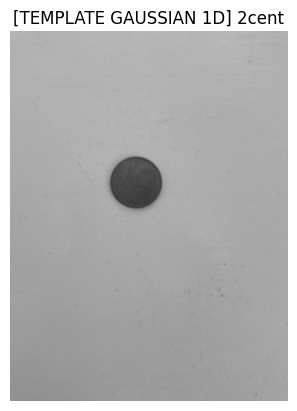

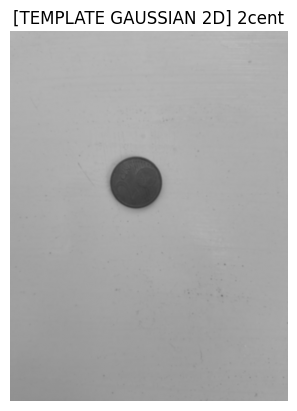

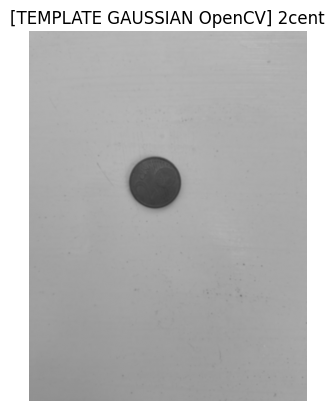

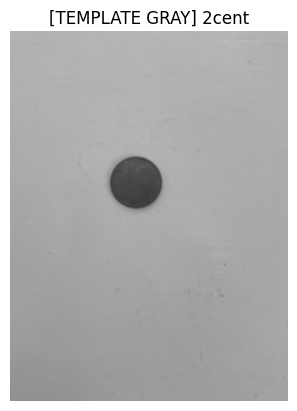

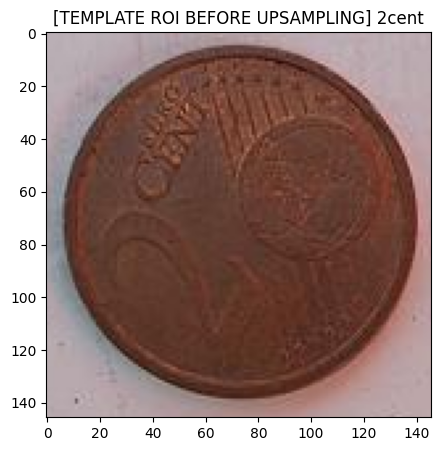

Original ROI size: 146x146
Upsampled ROI size: 256x256


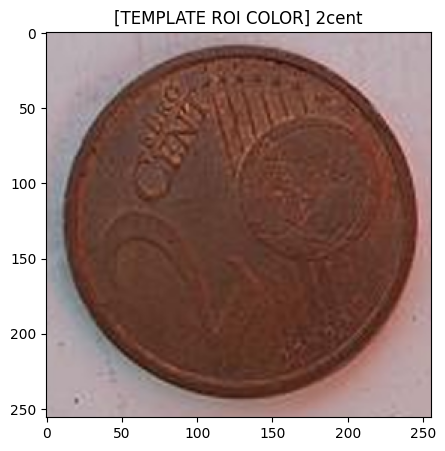

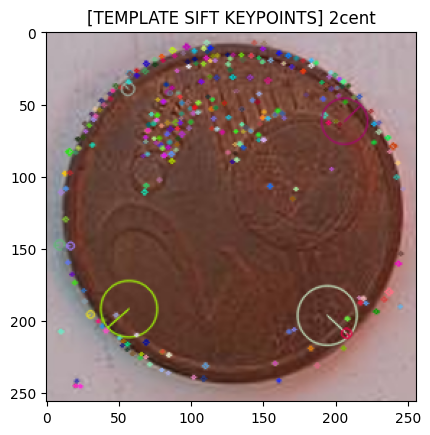

num keypoints: 328


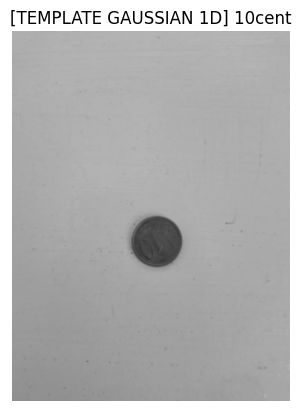

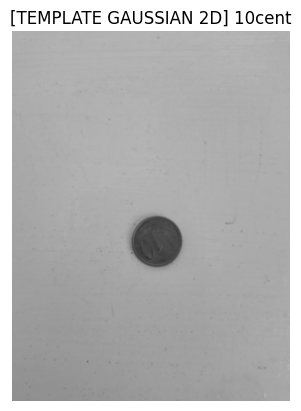

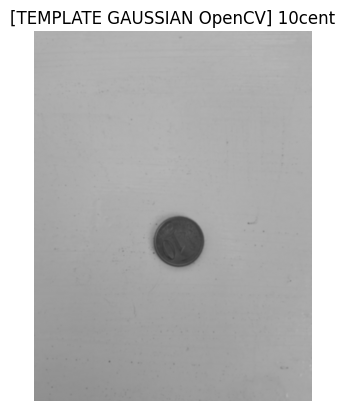

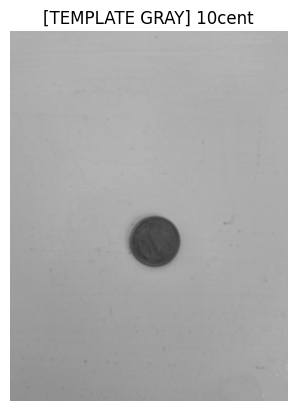

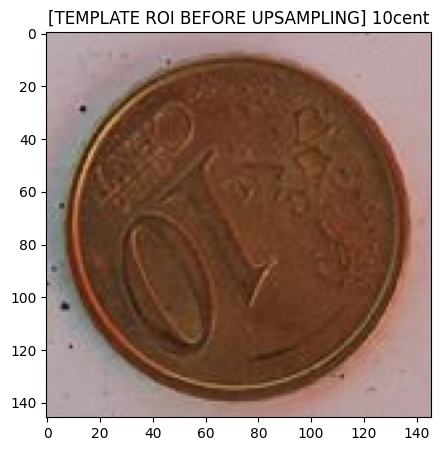

Original ROI size: 146x146
Upsampled ROI size: 256x256


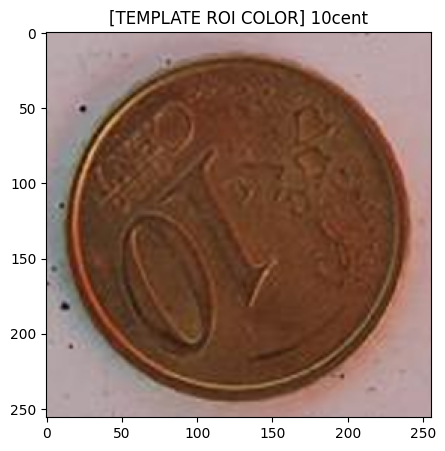

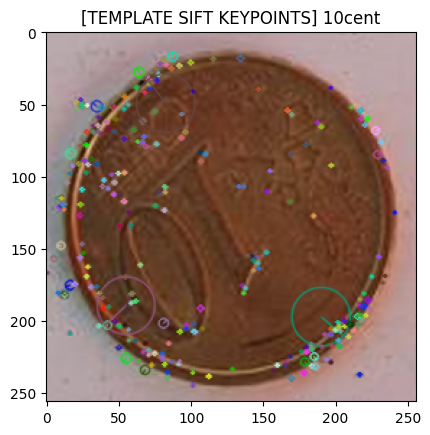

num keypoints: 295


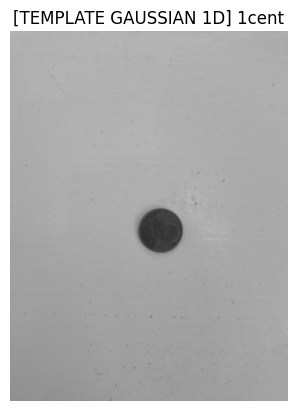

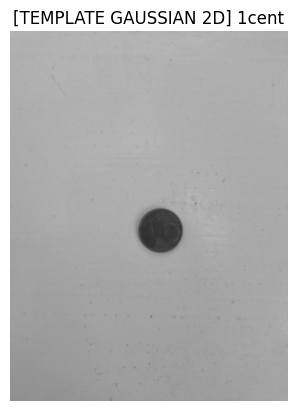

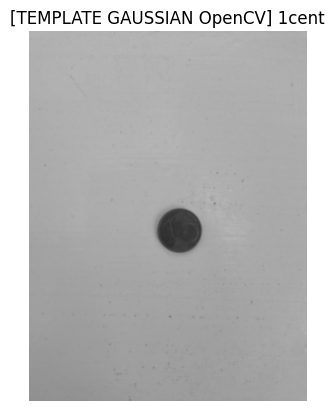

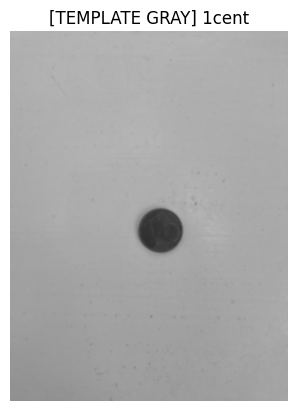

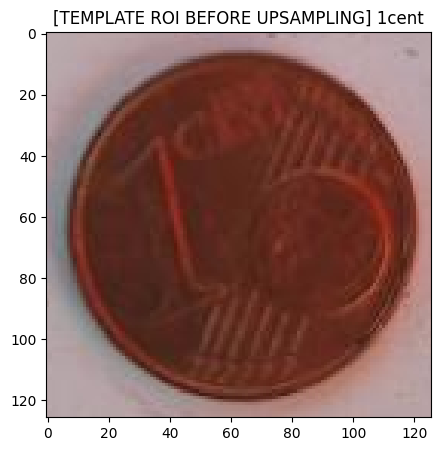

Original ROI size: 126x126
Upsampled ROI size: 256x256


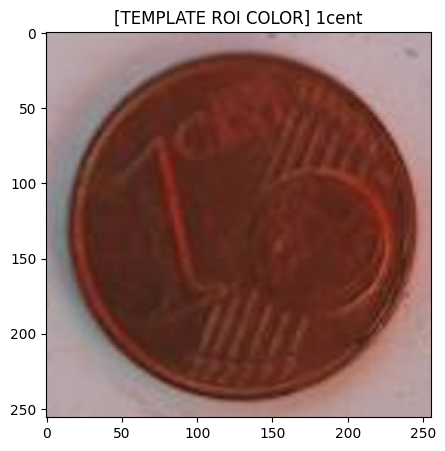

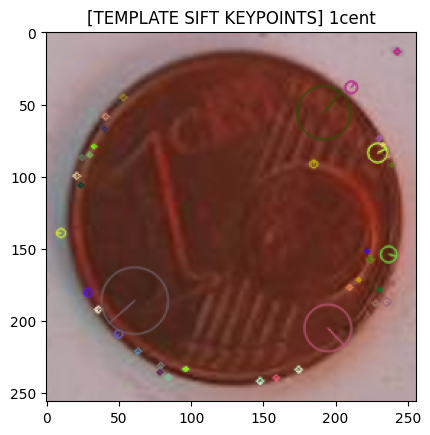

num keypoints: 44


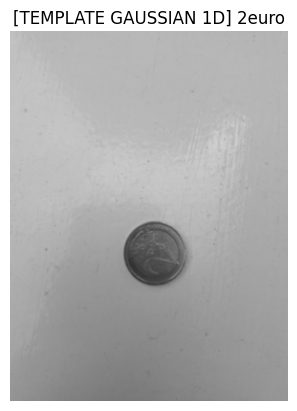

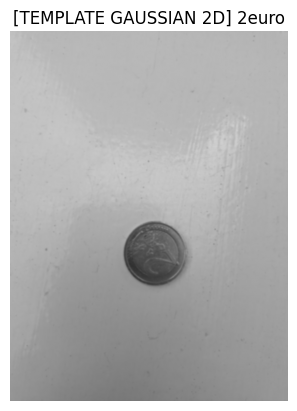

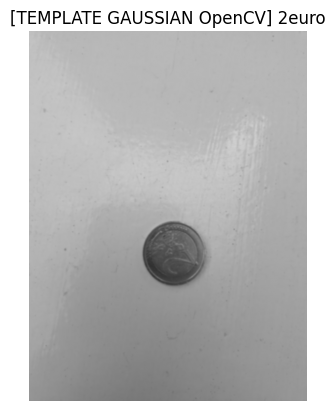

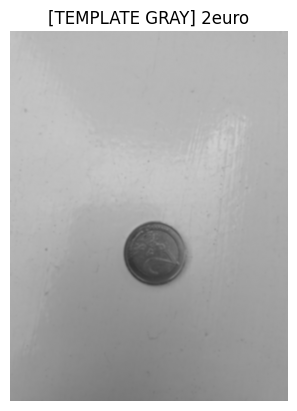

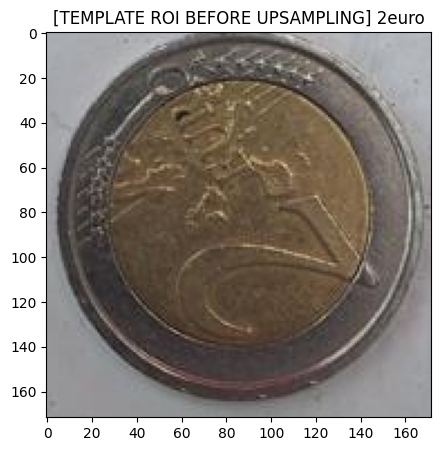

Original ROI size: 172x172
Upsampled ROI size: 256x256


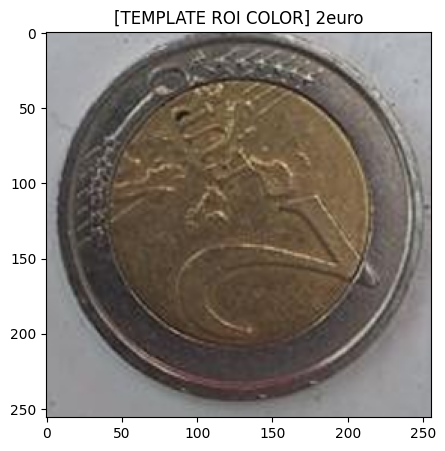

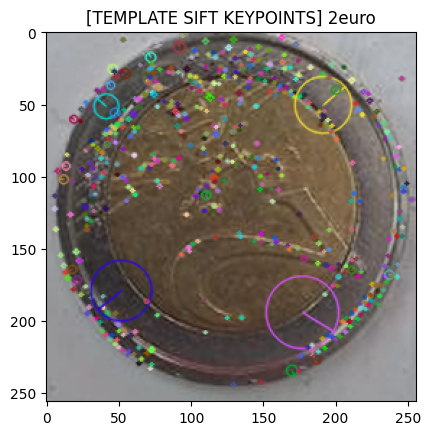

num keypoints: 579


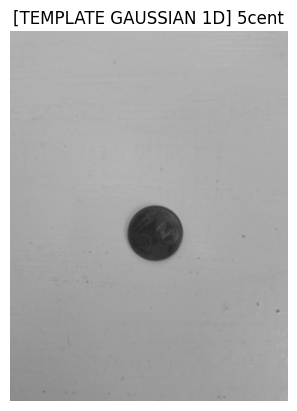

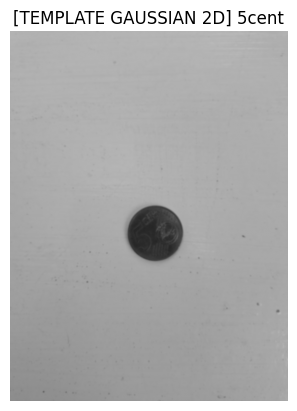

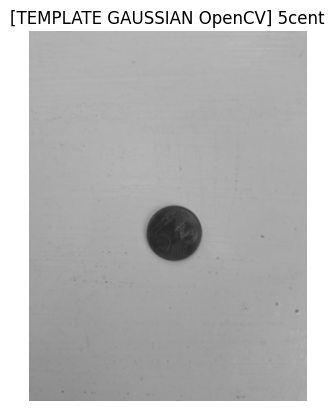

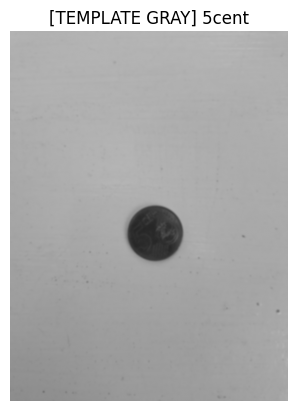

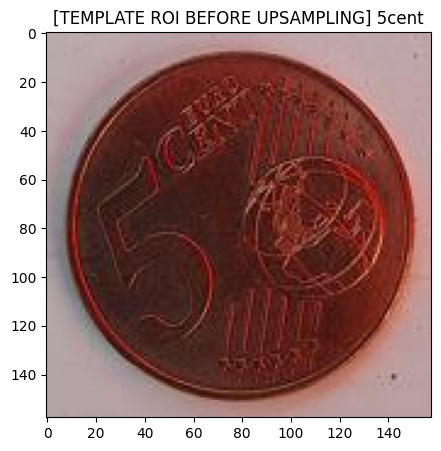

Original ROI size: 158x158
Upsampled ROI size: 256x256


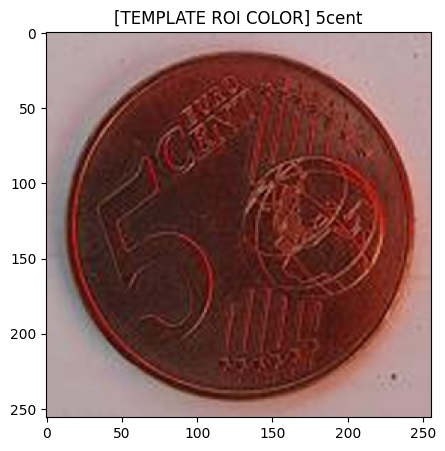

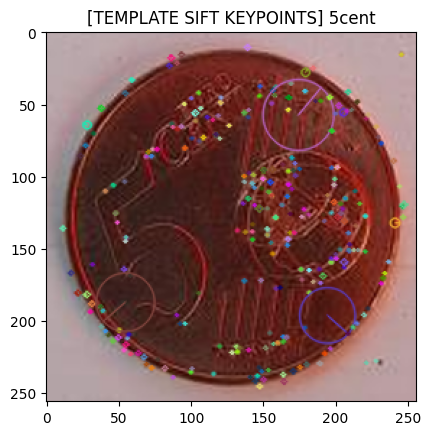

num keypoints: 315


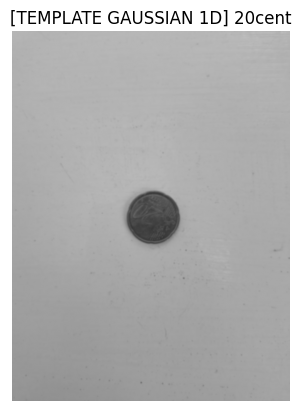

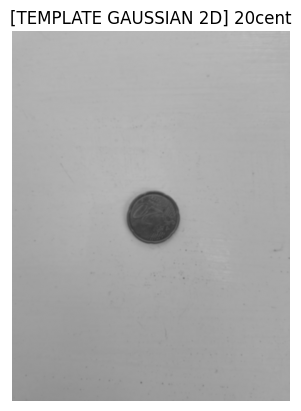

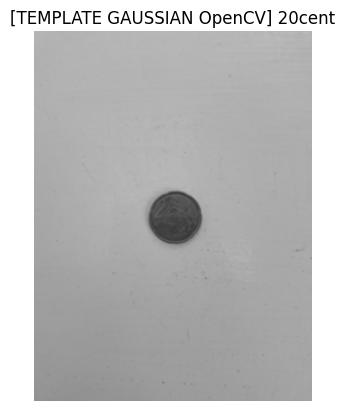

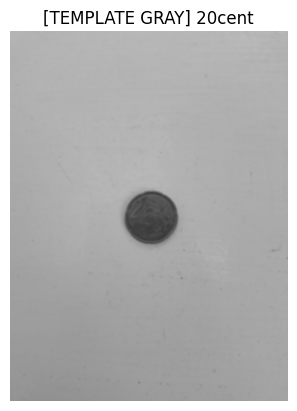

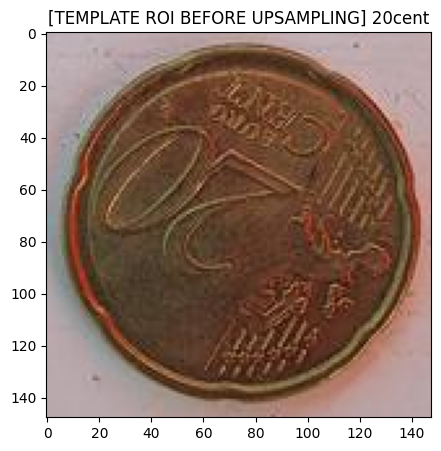

Original ROI size: 148x148
Upsampled ROI size: 256x256


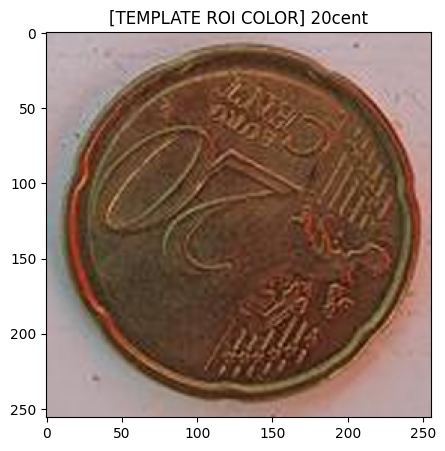

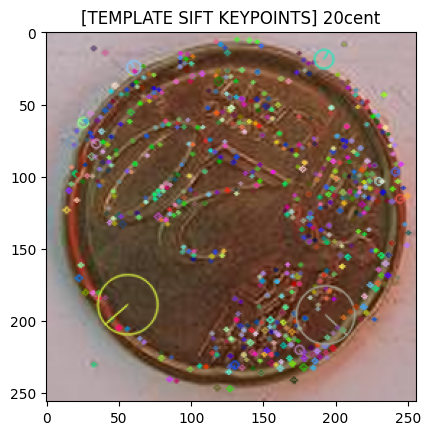

num keypoints: 765


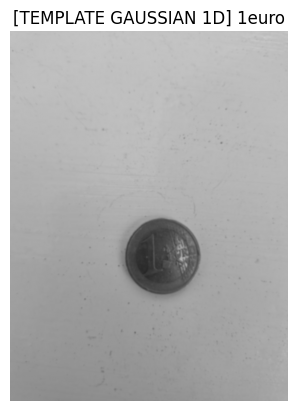

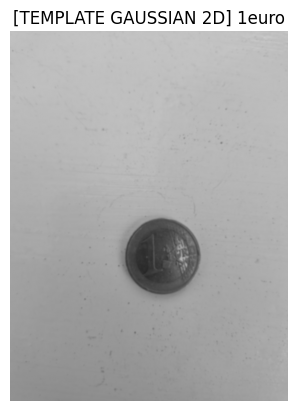

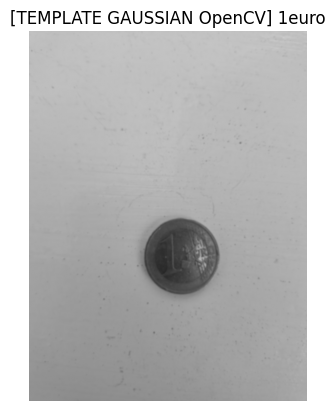

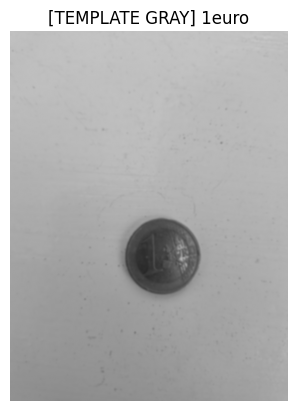

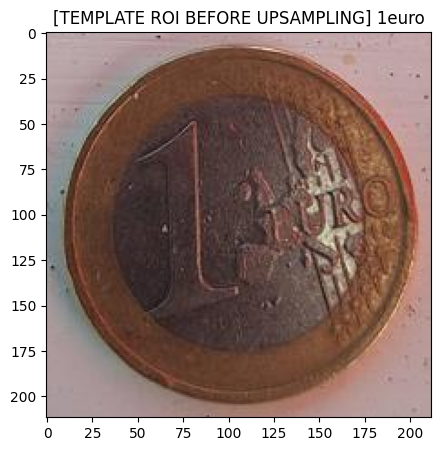

Original ROI size: 212x212
Upsampled ROI size: 256x256


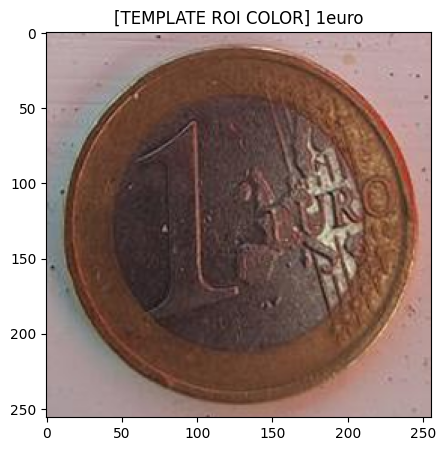

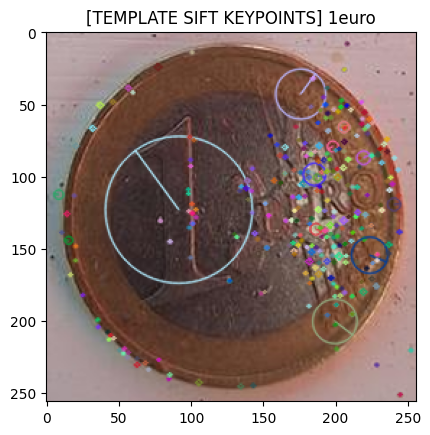

num keypoints: 332


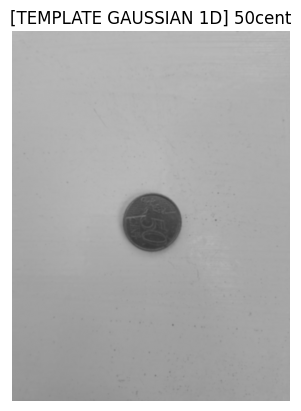

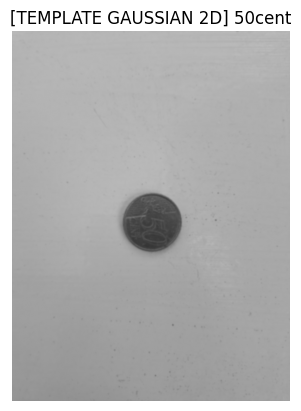

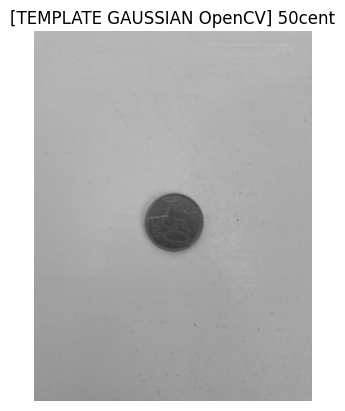

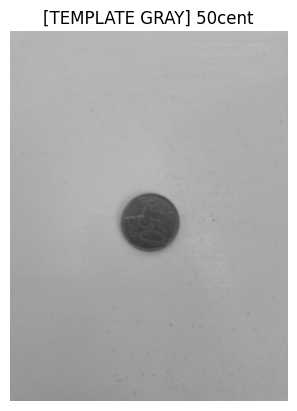

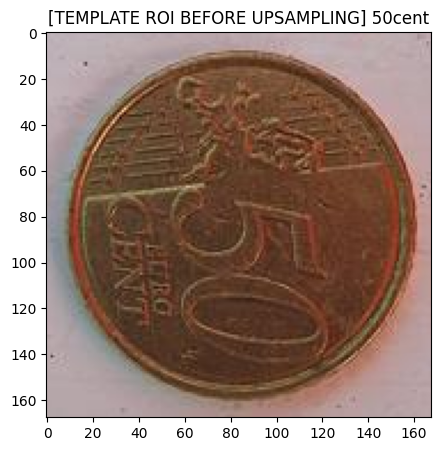

Original ROI size: 168x168
Upsampled ROI size: 256x256


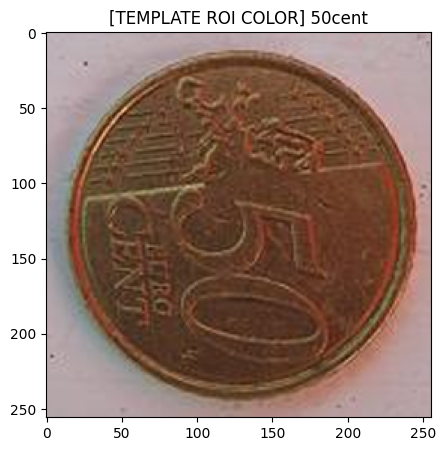

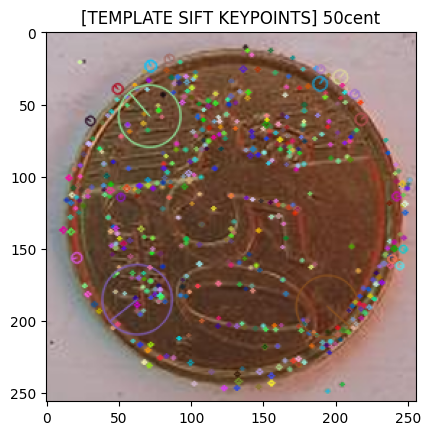

num keypoints: 605


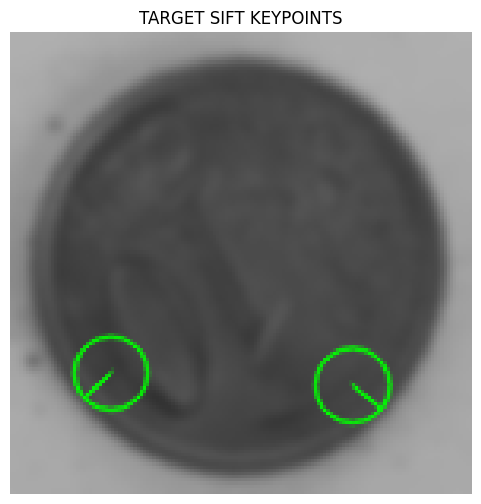


10cent.jpg
  Partial: 0.00 €


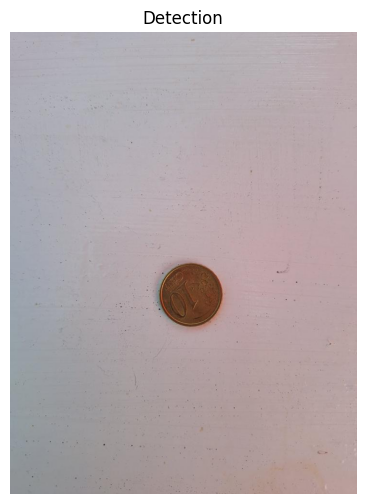


TOTAL: 0.00 €


In [10]:
import cv2
import numpy as np
from pathlib import Path
import time
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================

TARGET_DIR = "coin_dataset/target_set"
TEMPLATE_DIR = "coin_dataset/reference_set"

COIN_VALUES = {
    "1cent": 0.01,
    "2cent": 0.02,
    "5cent": 0.05,
    "10cent": 0.10,
    "20cent": 0.20,
    "50cent": 0.50,
    "1euro": 1.00,
    "2euro": 2.00
}

# ============================================================
# SIFT + FLANN
# ============================================================

sift = cv2.SIFT_create()

FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)

flann = cv2.FlannBasedMatcher(index_params, search_params)

# ============================================================
# TEMPLATE LOADING
# ============================================================

def normalize_coin_name(name):
    return name.lower().replace("_", "").replace(" ", "")



# ============================================================
# ROI
# ============================================================

def extract_roi(img, x, y, r):
    pad = int(r * 1.1)

    try:
        x1 = max(0, x - pad)
        x2 = min(img.shape[1], x + pad)
        y1 = max(0, y - pad)
        y2 = min(img.shape[0], y + pad)
    except:
        return None



    roi = img[y1:y2, x1:x2]

    if roi is None or roi.size == 0:
        return None

    return roi


# ============================================================
# PREPROCESS + VISUAL DEBUG (NEW)
# ============================================================

def preprocess(roi, debug=False):

    if roi is None or roi.shape[0] < 20 or roi.shape[1] < 20:
        return None

    # roi_resized = cv2.resize(roi, (256, 256))

    # gray = cv2.cvtColor(roi_resized, cv2.COLOR_BGR2GRAY)
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

    # 🔥 ADDED: Gaussian filter (your request)
    blurred = cv2.GaussianBlur(gray, (9, 9), 2)

    # if debug:
    #     plt.figure(figsize=(12,4))

    #     plt.subplot(1,3,1)
    #     plt.imshow(cv2.cvtColor(roi_resized, cv2.COLOR_BGR2RGB))
    #     plt.title("ROI")
    #     plt.axis("off")

    #     plt.subplot(1,3,2)
    #     plt.imshow(blurred, cmap="gray")
    #     plt.title("Gaussian Blur")
    #     plt.axis("off")

    #     plt.subplot(1,3,3)
    #     plt.imshow(gray, cmap="gray")
    #     plt.title("Final Gray")
    #     plt.axis("off")

    #     plt.show()

    return blurred  # IMPORTANT: we keep pipeline unchanged (SIFT gets this)


# def load_templates(debug=True):
#     templates = {}

#     for path in Path(TEMPLATE_DIR).glob("*.jpg"):
#         name = path.stem.lower().replace("_", "").replace(" ", "")

#         img = cv2.imread(str(path))

#         if img is None:
#             continue

#         # ============================================================
#         # STEP 1: PREPROCESS FOR HOUGH (same as target)
#         # ============================================================

#         gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#         blur = cv2.GaussianBlur(gray, (9, 9), 2)
#         edges = cv2.Canny(blur, 80, 160)

#         # ============================================================
#         # STEP 2: HOUGH CIRCLES
#         # ============================================================

#         circles = cv2.HoughCircles(
#             blur,
#             cv2.HOUGH_GRADIENT,
#             dp=1.5,
#             minDist=80,
#             param1=120,
#             param2=30,
#             minRadius=50,
#             maxRadius=140
#         )

#         if circles is None:
#             if debug:
#                 print(f"[TEMPLATE] No circles detected for {name}")
#             continue

#         circles = np.uint16(np.around(circles[0]))

#         x, y, r = circles[0]

#         # ============================================================
#         # STEP 3: ROI EXTRACTION (same function as target)
#         # ============================================================

#         roi = extract_roi(img, x, y, r)

#         if roi is None:
#             if debug:
#                 print(f"[TEMPLATE] ROI failed for {name}")
#             continue

#         # ============================================================
#         # STEP 4: PREPROCESS (same function as target)
#         # ============================================================

#         roi_gray = preprocess(roi, debug=False)

#         if roi_gray is None:
#             if debug:
#                 print(f"[TEMPLATE] Preprocess failed for {name}")
#             continue

#         # ============================================================
#         # STEP 5: SIFT
#         # ============================================================

#         kp, des = sift.detectAndCompute(roi_gray, None)

#         if des is None:
#             if debug:
#                 print(f"[TEMPLATE] No SIFT features for {name}")
#             continue

#         # ============================================================
#         # STEP 6: DEBUG VISUALIZATION (CORRECT IMAGE)
#         # ============================================================

#         # if debug:
#         #     img_kp = cv2.drawKeypoints(
#         #         roi_gray,
#         #         kp,
#         #         None,
#         #         (0, 255, 0),
#         #         cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
#         #     )

#         #     plt.figure(figsize=(5, 5))
#         #     plt.imshow(img_kp, cmap="gray")
#         #     plt.title(f"[TEMPLATE PROCESSED] {name}")
#         #     plt.axis("off")
#         #     plt.show()

#         # ============================================================
#         # STEP 7: STORE PROPERLY
#         # ============================================================

#         templates[name] = (roi_gray, kp, des)

#     return templates





# def load_templates(debug=True):
#     templates = {}

#     for path in Path(TEMPLATE_DIR).glob("*.jpg"):
#         name = normalize_coin_name(path.stem)

#         # img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)


#         img = cv2.imread(str(path))
#         img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#         # img = cv2.resize(img, (256, 256))



#         # ============================================================
#         # STEP 2: HOUGH CIRCLES
#         # ============================================================

#         circles = cv2.HoughCircles(
#             img,
#             cv2.HOUGH_GRADIENT,
#             dp=1.5,
#             minDist=80,
#             param1=120,
#             param2=30,
#             minRadius=50,
#             maxRadius=140
#         )

#         if circles is None:
#             if debug:
#                 print(f"[TEMPLATE] No circles detected for {name}")
#             continue

#         circles = np.uint16(np.around(circles[0]))

#         x, y, r = circles[0]

#         # ============================================================
#         # STEP 3: ROI EXTRACTION (same function as target)
#         # ============================================================

#         roi = extract_roi(img, x, y, r)

#         if roi is None:
#             if debug:
#                 print(f"[TEMPLATE] ROI failed for {name}")
#             continue

        


#         # show debug visuals for ROI
#         if debug:
#             plt.figure(figsize=(5, 5))
#             plt.imshow(roi, cmap="gray")
#             plt.title(f"[TEMPLATE ROI] {name}")
#             plt.axis("off")
#             plt.show()

#         # save the image of roi 
#         cv2.imwrite(f"debug_templates/{name}_roi.jpg", roi)

#         sift = cv2.SIFT_create()
#         kp = sift.detect(roi, None)
#         img_visualization = cv2.drawKeypoints(roi, kp, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
#         plt.imshow(img_visualization)
#         plt.show()

#         # kp, des = sift.detectAndCompute(img, None)

#         # if des is not None:
#         #     templates[name] = (kp, des)

#         # # show debug visuals for templates with SIFT keypoints
#         # if des is not None:
#         #     img_kp = cv2.drawKeypoints(
#         #         roi,
#         #         kp,
#         #         None,
#         #         (0, 255, 0),
#         #         cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
#         #     )

#         #     plt.figure(figsize=(5, 5))
#         #     plt.imshow(img_kp, cmap="gray")
#         #     plt.title(f"[TEMPLATE PROCESSED] {name}")
#         #     plt.axis("off")
#         #     plt.show()

#     return templates


def load_templates(debug=True):
    templates = {}

    for path in Path(TEMPLATE_DIR).glob("*.jpg"):
        name = normalize_coin_name(path.stem)

        # ============================================================
        # LOAD IMAGE (KEEP COLOR + GRAY)
        # ============================================================
        img_color = cv2.imread(str(path))  # BGR (KEEP THIS)
        img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)





        # ============================================================
        # gaussian filter
        # ============================================================

                
        # Calculate k_size
        sigma = 1.5
        k_size = int(np.ceil((3*sigma))*2 + 1)  # rule of thumb for a good kernel size given sigma

        # Find the 1D Gaussian kernel
        gaussian_kernel_1D = cv2.getGaussianKernel(k_size, sigma)
        

        # Apply the kernel
        start = time.time()
        img_tr = cv2.filter2D(img_gray, -1, gaussian_kernel_1D)
        img_tr = cv2.filter2D(img_tr, -1, gaussian_kernel_1D.transpose())
        end = time.time()
        # print(f"\nTime needed to apply a 1D convolution twice: {(end - start):.3f} seconds.")


        # Display the image after filtering
        plt.imshow(img_tr, cmap="gray", vmin=0, vmax=255)
        plt.title(f"[TEMPLATE GAUSSIAN 1D] {name}")
        plt.axis("off")
        plt.show()

        # Find the 2D Gaussian kernel
        gaussian_kernel_2D = gaussian_kernel_1D.dot(gaussian_kernel_1D.transpose())

        # Apply the kernel
        start = time.time()
        img_tr = cv2.filter2D(img_gray, -1, gaussian_kernel_2D)
        end = time.time()
        # print(f"\nTime needed to apply a single 2D convolution: {(end - start):.3f} seconds.")

        # img_gray = img_tr  # update img_gray for next steps

        # Display the image after filtering
        plt.imshow(img_tr, cmap="gray", vmin=0, vmax=255)
        plt.title(f"[TEMPLATE GAUSSIAN 2D] {name}")
        plt.axis("off")
        plt.show()

        # Use the OpenCV function GaussianBlur
        start = time.time()
        img_tr = cv2.GaussianBlur(img_gray, (k_size, k_size), sigma)
        end = time.time()
        # print(f"\nTime needed to apply the OpenCV API: {(end - start):.3f} seconds.")

        # Display the image after filtering
        plt.imshow(img_tr, cmap="gray", vmin=0, vmax=255)
        plt.title(f"[TEMPLATE GAUSSIAN OpenCV] {name}")
        plt.axis("off")
        plt.show()


        k_size = 9
        sigma = 2
        img_gray = cv2.GaussianBlur(img_gray, (k_size, k_size), sigma)

        plt.imshow(img_gray, cmap="gray", vmin=0, vmax=255)
        plt.title(f"[TEMPLATE GRAY] {name}")
        plt.axis("off")
        plt.show()



        # ============================================================
        # mean filter
        # ============================================================
        
        # k_size = 9
        # mean_kernel = np.ones([k_size, k_size])/(k_size**2)

        # img_gray = cv2.filter2D(img_gray, -1, mean_kernel)

        # plt.imshow(img_gray, cmap="gray", vmin=0, vmax=255)
        # plt.title(f"[TEMPLATE GRAY mean] {name}")
        # plt.axis("off")
        # plt.show()



        # # ============================================================
        # # bilateral filter
        # # ============================================================
        
        # img_bilateral = cv2.bilateralFilter(img_gray, d=9, sigmaColor=75, sigmaSpace=75)
        # plt.imshow(img_bilateral, cmap="gray", vmin=0, vmax=255)
        # plt.title(f"[TEMPLATE GRAY bilateral] {name}")
        # plt.axis("off")
        # plt.show()

        # # img_gray = img_bilateral  # update img_gray for next steps



        # # ============================================================
        # # Sobel filter
        # # ============================================================

        # # Define sobel kernels
        # sobel_kernel_x = np.array([[-1,0,1],[-2,0,2],[-1,0,1]]) * 1/4
        # sobel_kernel_y = np.array([[-1,-2,-1],[0,0,0],[1,2,1]]) * 1/4

        # # Compute |dI(x,y)/dx|
        # dx = cv2.filter2D(img_gray.astype(float), -1, sobel_kernel_x)
        # dx = np.abs(dx)

        # # Display dx
        # plt.imshow(dx, cmap="gray", vmin=0, vmax=255)
        # plt.show()

        # # Compute |dI(x,y)/dy|
        # dy = cv2.filter2D(img_gray.astype(float), -1, sobel_kernel_y)
        # dy = np.abs(dy)

        # # Display dy
        # plt.imshow(dy, cmap="gray", vmin=0, vmax=255)
        # plt.show()

        # # Compute the pixel-wise gradient module
        # sobel = np.maximum(dx, dy)

        # # Display the gradient module
        # plt.imshow(sobel, cmap="gray", vmin=0, vmax=255)
        # plt.show()


        # ============================================================
        # CANNY EDGE (USE BLURRED IMAGE)
        # ============================================================

        # edges = cv2.Canny(img_gray, 80, 160)

        # plt.imshow(edges, cmap="gray")
        # plt.title(f"[TEMPLATE CANNY EDGES] {name}")
        # plt.axis("off")
        # plt.show()

        # ============================================================
        # HOUGH CIRCLES (USE GRAYSCALE ONLY)
        # ============================================================
        circles = cv2.HoughCircles(
            img_gray,
            # edges,
            cv2.HOUGH_GRADIENT,
            dp=1.5,
            minDist=80,
            param1=120,
            param2=30,
            minRadius=50,
            maxRadius=140
        )

        if circles is None:
            if debug:
                print(f"[TEMPLATE] No circles detected for {name}")
            continue

        circles = np.uint16(np.around(circles[0]))
        x, y, r = circles[0]

        # ============================================================
        # ROI FROM COLOR IMAGE (IMPORTANT FIX)
        # ============================================================
        roi = extract_roi(img_color, x, y, r)

        if roi is None:
            if debug:
                print(f"[TEMPLATE] ROI failed for {name}")
            continue
        

        # ============================================================
        # Upsampeling image
        # ============================================================
        plt.figure(figsize=(5, 5))
        plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
        plt.title(f"[TEMPLATE ROI BEFORE UPSAMPLING] {name}")
        # plt.axis("off")
        plt.show()

        print(f"Original ROI size: {roi.shape[1]}x{roi.shape[0]}")
        roi = cv2.resize(roi, (256, 256), interpolation=cv2.INTER_CUBIC)
        print(f"Upsampled ROI size: {roi.shape[1]}x{roi.shape[0]}")
    


        # ============================================================
        # DEBUG SHOW COLOR ROI
        # ============================================================
        if debug:
            plt.figure(figsize=(5, 5))
            plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
            plt.title(f"[TEMPLATE ROI COLOR] {name}")
            # plt.axis("off")
            plt.show()

        cv2.imwrite(f"debug_templates/{name}_roi.jpg", roi)

        # ============================================================
        # SIFT (CONVERT ROI TO GRAY ONLY FOR FEATURES)
        # ============================================================
        sift = cv2.SIFT_create()
        roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)

        kp = sift.detect(roi_gray, None)

        img_visualization = cv2.drawKeypoints(
            roi_gray,
            kp,
            None,
            flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
        )

        plt.imshow(img_visualization)
        plt.title(f"[TEMPLATE SIFT KEYPOINTS] {name}")
        # plt.axis("off")
        plt.show()
        print("num keypoints:", len(kp))


        # ============================================================
        # BRISK (ADDED ALTERNATIVE FEATURE DETECTOR)
        # ============================================================
        # brisk = cv2.BRISK_create()
        # kp_brisk = brisk.detect(roi_gray, None)

        # img_visualization_brisk = cv2.drawKeypoints(
        #     roi_gray,
        #     kp_brisk,
        #     None,
        #     flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
        # )

        # plt.imshow(img_visualization_brisk)
        # plt.title(f"[TEMPLATE BRISK KEYPOINTS] {name}")
        # # plt.axis("off")
        # plt.show()
        # print("num keypoints (BRISK):", len(kp_brisk))


        # # ============================================================
        # # ORB (ADDED ALTERNATIVE FEATURE DETECTOR)
        # # ============================================================
        # orb = cv2.ORB_create()
        # kp_orb = orb.detect(roi_gray, None)

        # img_visualization_orb = cv2.drawKeypoints(
        #     roi_gray,
        #     kp_orb,
        #     None,
        #     flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
        # )

        # plt.imshow(img_visualization_orb)
        # plt.title(f"[TEMPLATE ORB KEYPOINTS] {name}")
        # # plt.axis("off")
        # plt.show()
        # print("num keypoints (ORB):", len(kp_orb))


    return templates

templates_db = load_templates()




# ============================================================
# CIRCLE DETECTION (UNCHANGED LOGIC)
# ============================================================

def detect_circles(gray):

    blur = cv2.GaussianBlur(gray, (9, 9), 2)
    edges = cv2.Canny(blur, 80, 160)

    circles = cv2.HoughCircles(
        # edges,
        blur,
        cv2.HOUGH_GRADIENT,
        dp=1.5,
        minDist=80,
        param1=120,
        param2=30,
        minRadius=50,
        maxRadius=140
    )

    # debug_img = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

    # if circles is not None:
    #     print("Raw circles detected:", len(circles[0]))

    #     for (x, y, r) in np.uint16(np.around(circles[0])):
    #         cv2.circle(debug_img, (x, y), r, (255, 0, 0), 2)  # blue circles
    # else:
    #     print("Raw circles detected: 0")

    # plt.figure(figsize=(6, 6))
    # plt.imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
    # plt.title("RAW Hough Circles (Before Filtering)")
    # plt.axis("off")
    # plt.show()


    if circles is None:
        return []

    circles = np.uint16(np.around(circles[0]))

    filtered = []
    print(f"Detected {len(circles)} circles, filtering...")
    
    for (x, y, r) in circles:

        mask = np.zeros(gray.shape, dtype=np.uint8)
        cv2.circle(mask, (x, y), r, 255, 2)

        score = np.sum(edges & mask) / (np.sum(mask > 0) + 1)
        print(f"Circle at ({x}, {y}), r={r}: score={score:.4f}")
        if score < 0.25:
            continue

        filtered.append((x, y, r))

    return filtered

# ============================================================
# CLASSIFIER (UNCHANGED)
# ============================================================

def classify_coin(roi_gray):

    # ============================================================
    # STEP 1: SIFT on target coin
    # ============================================================

    kp1, des1 = sift.detectAndCompute(
        roi_gray,
        None
    )

    img_with_keypoints = cv2.drawKeypoints(
        roi_gray,
        kp1,
        None,
        (0,255,0),
        cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )

    plt.figure(figsize=(6,6))
    plt.imshow(img_with_keypoints)
    plt.title("TARGET SIFT KEYPOINTS")
    plt.axis("off")
    plt.show()

    if des1 is None or len(des1) < 4:
        return None

    des1 = np.float32(des1)

    best = None
    best_score = 0

    # ============================================================
    # STEP 2: compare with templates
    # ============================================================

    # for name, (template_img, kp2, des2) in templates_db.items():

    for name, (kp2, des2) in templates_db.items():

        if des2 is None:
            continue

        des2 = np.float32(des2)

        try:
            matches = flann.knnMatch(
                des1,
                des2,
                k=2
            )

        except:
            continue

        # ============================================================
        # Lowe ratio test
        # ============================================================

        good = []

        for m_n in matches:

            if len(m_n) != 2:
                continue

            m, n = m_n

            if m.distance < 0.75 * n.distance:
                good.append(m)

        # score = len(good) / (len(matches) + 1e-6)

        # confidence = len(good) / (len(des1) + 1e-6)

        # final_score = score * confidence

        # Option A — ratio of good matches to target descriptors (simpler, cleaner)
        final_score = len(good) / (len(des1) + 1e-6)

        # Option B — also normalize by template size (good for unbalanced kp counts)
        final_score = len(good) / (min(len(des1), len(des2)) + 1e-6)

        # ============================================================
        # DEBUG PRINT
        # ============================================================

        print("\n----------------")
        print("Template:", name)

        print(
            "Target kp:",
            len(des1)
        )

        print(
            "Template kp:",
            len(des2)
        )

        print(
            "Raw matches:",
            len(matches)
        )

        print(
            "Good matches:",
            len(good)
        )

        # print(
        #     "Score:",
        #     round(score,5)
        # )

        # print(
        #     "Confidence:",
        #     round(confidence,5)
        # )

        print(
            "FINAL:",
            round(final_score,5)
        )

        # ============================================================
        # keep best match
        # ============================================================

        if final_score > best_score:

            best_score = final_score
            best = name

    print(
        "\nBEST:",
        best,
        " SCORE:",
        best_score
    )

    if best_score < 0.002:
        return None

    return best

# ============================================================
# PROCESS IMAGE (WITH DEBUG VISUALS ADDED)
# ============================================================

def process_image(img_path, debug=False):

    img = cv2.imread(str(img_path))
    if img is None:
        return [], 0, None

    # ============================================================
    # STEP 1: SAME PREPROCESSING AS TEMPLATE (for HoughCircles)
    # ============================================================

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (9, 9), 2)

    # ============================================================
    # STEP 2: CIRCLE DETECTION
    # ============================================================

    circles = cv2.HoughCircles(
        blur,
        cv2.HOUGH_GRADIENT,
        dp=1.5,
        minDist=80,
        param1=120,
        param2=30,
        minRadius=50,
        maxRadius=140
    )

    detected = []
    total = 0

    vis = img.copy()

    if circles is None:
        return [], 0, vis

    circles = np.uint16(np.around(circles[0]))

    # ============================================================
    # DEBUG: show detected circles
    # ============================================================

    # if debug:
    #     debug_img = img.copy()
    #     for (x, y, r) in circles:
    #         cv2.circle(debug_img, (x, y), r, (255, 0, 0), 2)

    #     plt.figure(figsize=(5,5))
    #     plt.imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
    #     plt.title("[TARGET] Hough Circles")
    #     plt.axis("off")
    #     plt.show()

    # ============================================================
    # STEP 3: PROCESS EACH CIRCLE
    # ============================================================

    for (x, y, r) in circles:

        # ROI extraction (same as template)
        roi = extract_roi(img, x, y, r)

        if roi is None:
            continue

        # preprocessing (same as template)
        roi_gray = preprocess(roi, debug=False)

        if roi_gray is None:
            continue

        # classification
        coin = classify_coin(roi_gray)

        if coin is None:
            continue

        value = COIN_VALUES.get(coin, 0)

        detected.append((coin, value))
        total += value

        # ============================================================
        # VISUALIZATION (same style as template debug)
        # ============================================================

        cv2.circle(vis, (x, y), r, (0, 255, 0), 2)
        cv2.putText(
            vis,
            coin,
            (x - 20, y),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1
        )

    return detected, total, vis

# ============================================================
# RUN
# ============================================================

grand_total = 0

for img_path in Path(TARGET_DIR).glob("*.jpg"):

    coins, total, vis = process_image(img_path, debug=True)

    print(f"\n{img_path.name}")

    for c, v in coins:
        print(f"  {c}: {v}")

    print(f"  Partial: {total:.2f} €")

    grand_total += total

    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title("Detection")
    plt.axis("off")
    plt.show()

print("\n====================")
print(f"TOTAL: {grand_total:.2f} €")

